<a href="https://colab.research.google.com/github/europecodingschool/ECS---VB---YZ---08.26/blob/main/VB_YZ_Ders_14_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
veri = pd.read_csv("/content/kargo_gecikme.csv")

In [28]:
veri.head()

,mesafe_km,hava_durumu,kurye_deneyim_ay,aktarma_sayisi,hafta_sonu,paket_agirlik_kg,gecikti
0,301,Acik,10,1,0,2.1,0
1,402,Karli,18,0,0,3.6,0
2,266,Yagmurlu,4,1,1,2.8,1
3,240,Yagmurlu,4,1,0,5.4,1
4,435,Yagmurlu,8,1,0,11.3,0


In [29]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mesafe_km         1500 non-null   int64  
 1   hava_durumu       1500 non-null   object 
 2   kurye_deneyim_ay  1500 non-null   int64  
 3   aktarma_sayisi    1500 non-null   int64  
 4   hafta_sonu        1500 non-null   int64  
 5   paket_agirlik_kg  1500 non-null   float64
 6   gecikti           1500 non-null   int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 82.2+ KB


In [30]:
veri.isnull().sum() # verimizde boş değer yok.

,0
mesafe_km,0
hava_durumu,0
kurye_deneyim_ay,0
aktarma_sayisi,0
hafta_sonu,0
paket_agirlik_kg,0
gecikti,0


In [31]:
veri.duplicated().sum() #veri setimizde tekrar eden satır yok.

np.int64(0)

In [32]:
veri["gecikti"].value_counts()

,count
gecikti,
0,1017
1,483


In [33]:
veri["gecikti"].value_counts(normalize=True)

,proportion
gecikti,
0,0.678
1,0.322


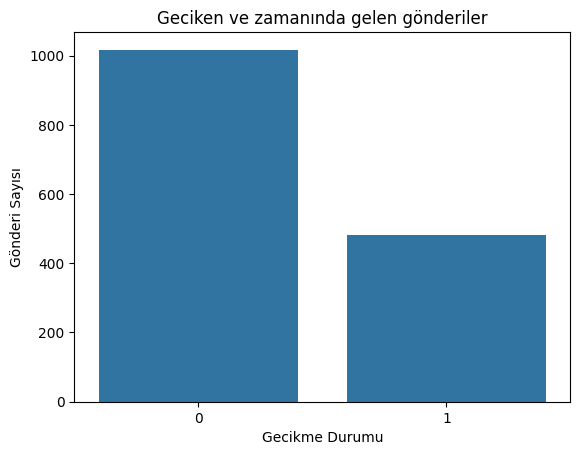

In [34]:
sns.countplot(data=veri, x='gecikti')
plt.title("Geciken ve zamanında gelen gönderiler")
plt.xlabel("Gecikme Durumu")
plt.ylabel("Gönderi Sayısı")
plt.show()

In [35]:
hava_orani = veri.groupby("hava_durumu")["gecikti"].mean()
hava_orani

,gecikti
hava_durumu,
Acik,0.189336
Karli,0.609756
Yagmurlu,0.501199


In [36]:
veri = pd.get_dummies(veri, columns=["hava_durumu"],drop_first=True, dtype=int)
veri.head()

,mesafe_km,kurye_deneyim_ay,aktarma_sayisi,hafta_sonu,paket_agirlik_kg,gecikti,hava_durumu_Karli,hava_durumu_Yagmurlu
0,301,10,1,0,2.1,0,0,0
1,402,18,0,0,3.6,0,1,0
2,266,4,1,1,2.8,1,0,1
3,240,4,1,0,5.4,1,0,1
4,435,8,1,0,11.3,0,0,1


In [38]:
# X ve y olarak ayır.

X = veri.drop("gecikti", axis=1)
y = veri["gecikti"]

In [41]:
#Train ve test olarak ayırma
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [43]:
# Tek ağaç

from sklearn.tree import DecisionTreeClassifier

agac = DecisionTreeClassifier(random_state=42)
agac.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy_score(y_test, agac.predict(X_test))

0.7733333333333333

In [49]:
# Bagging - 100 tane ağacı oylat

from sklearn.ensemble import BaggingClassifier


In [53]:
bagging = BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, random_state=42)
bagging.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                  random_state=42)

In [57]:
bagging.score(X_test, y_test)

0.8133333333333334

In [59]:
#Random Forest

from sklearn.ensemble import RandomForestClassifier

orman = RandomForestClassifier(n_estimators=100, random_state=42)
orman.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [61]:
orman.score(X_test, y_test)

0.8566666666666667

In [63]:
orman_10 = RandomForestClassifier(n_estimators=10, random_state=42)
orman_10.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [65]:
orman_100 = RandomForestClassifier(n_estimators=100, random_state=42)
orman_100.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [67]:
orman_300 = RandomForestClassifier(n_estimators=300, random_state=42)
orman_300.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [70]:
print(orman_10.score(X_test, y_test))
print(orman_100.score(X_test, y_test))
print(orman_300.score(X_test, y_test))

0.8333333333333334
0.8566666666666667
0.85


In [72]:
onem = pd.Series(orman.feature_importances_, index=X.columns)
onem.sort_values(ascending=False)

,0
mesafe_km,0.307489
kurye_deneyim_ay,0.191884
paket_agirlik_kg,0.150631
aktarma_sayisi,0.111064
hafta_sonu,0.105014
hava_durumu_Yagmurlu,0.072908
hava_durumu_Karli,0.061011


In [79]:
agac3 = DecisionTreeClassifier(max_depth=4, min_impurity_decrease=0.005,random_state=42)
agac3.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, min_impurity_decrease=0.005,
                       random_state=42)

In [80]:
accuracy_score(y_test, agac3.predict(X_test))

0.8033333333333333